**ML**

NAME - Mohammad SA

ANN MODEL

In [20]:
!pip install ucimlrepo tensorflow scikit-learn pandas numpy matplotlib seaborn


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


**HANDWRITTEN DIGIT DATASET**

In [22]:
from ucimlrepo import fetch_ucirepo

optical = fetch_ucirepo(id=80)

X = optical.data.features
y = optical.data.targets

print(optical.metadata)

print(optical.variables)


{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'ID': 280, 'type': 'NATIVE', 'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'venue': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, 

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

y = np.ravel(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

X_train.shape, y_train_cat.shape


((4496, 64), (4496, 10))

In [27]:
model_digits = Sequential([
    Dense(64, activation='relu', input_shape=(64,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model_digits.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

model_digits.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_digits = model_digits.fit(
    X_train, y_train_cat,
    validation_split=0.4,
    epochs=25,
    batch_size=32,
    verbose=1
)


Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9834 - loss: 0.0521 - val_accuracy: 0.9844 - val_loss: 0.0559
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9849 - loss: 0.0442 - val_accuracy: 0.9850 - val_loss: 0.0568
Epoch 3/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9882 - loss: 0.0418 - val_accuracy: 0.9822 - val_loss: 0.0574
Epoch 4/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9868 - loss: 0.0443 - val_accuracy: 0.9800 - val_loss: 0.0573
Epoch 5/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9825 - loss: 0.0518 - val_accuracy: 0.9850 - val_loss: 0.0530
Epoch 6/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9880 - loss: 0.0405 - val_accuracy: 0.9839 - val_loss: 0.0533
Epoch 7/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9832 - loss: 0.0537 - val_accuracy: 0.9839 - val_loss: 0.0522
Epoch 8/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9854 - loss: 0.0454 - val_accuracy: 0.9855 - val_

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 0.9768683274021353
Precision: 0.9770232292052856
Recall: 0.9768683274021353
F1 Score: 0.9768498493738478


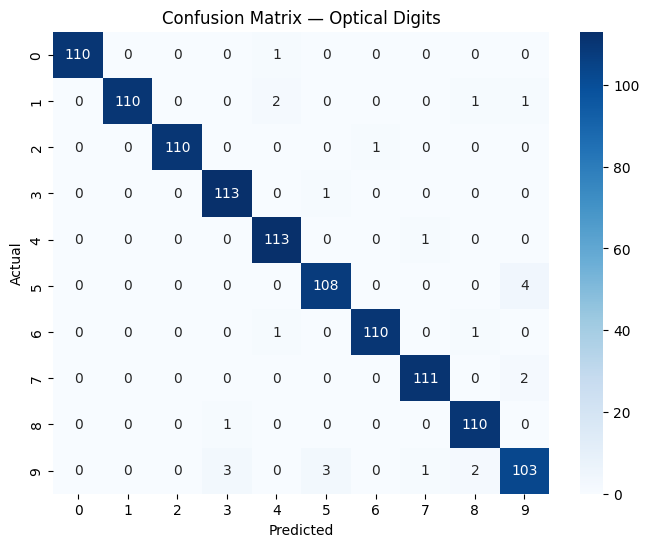

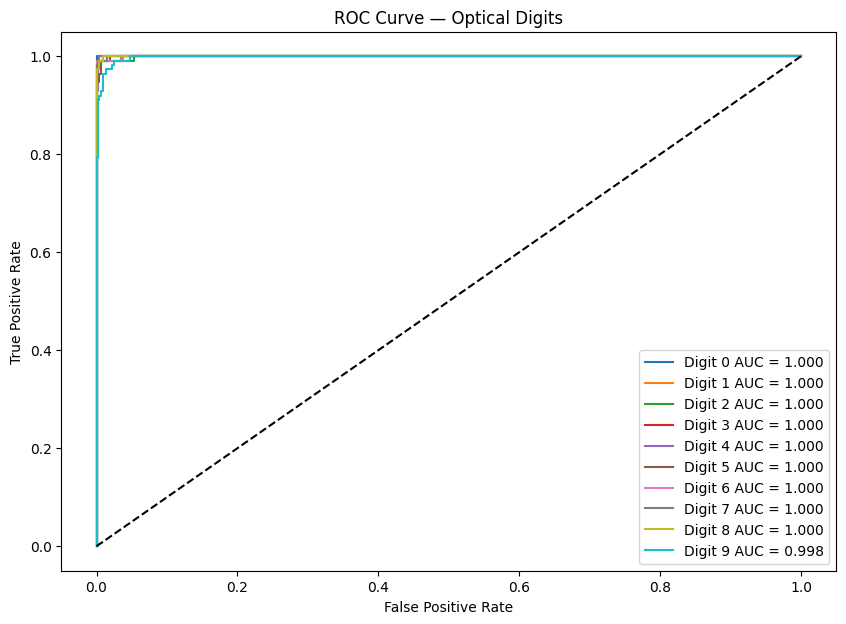

In [32]:
y_pred_prob = model_digits.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Optical Digits")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr = {}
tpr = {}
roc_auc = {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10,7))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f"Digit {i} AUC = {roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Optical Digits")
plt.legend()
plt.show()


**LETTER RECOGNITION DATASET**

In [33]:
from ucimlrepo import fetch_ucirepo

letter_recognition = fetch_ucirepo(id=59)

X = letter_recognition.data.features
y = letter_recognition.data.targets

print(letter_recognition.metadata)

print(letter_recognition.variables)


{'uci_id': 59, 'name': 'Letter Recognition', 'repository_url': 'https://archive.ics.uci.edu/dataset/59/letter+recognition', 'data_url': 'https://archive.ics.uci.edu/static/public/59/data.csv', 'abstract': 'Database of character image features; try to identify the letter', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 20000, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['lettr'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Thu Sep 28 2023', 'dataset_doi': '10.24432/C5ZP40', 'creators': ['David Slate'], 'intro_paper': None, 'additional_info': {'summary': 'The objective is to identify each of a large number of black-and-white rectangular pixel displays as one of the 26 capital letters in the English alphabet.  The character images were based on 20 different fonts and each letter within these 20 fonts wa

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical

y = np.ravel(y)


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train_cat = to_categorical(y_train, num_classes=26)
y_test_cat = to_categorical(y_test, num_classes=26)

X_train.shape, y_train_cat.shape

((16000, 16), (16000, 26))

In [40]:
model_letter = Sequential([
    Dense(64, activation='relu', input_shape=(16,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(26, activation='softmax')
])

model_letter.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

model_letter.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,026 (15.73 KB)

 Trainable params: 4,026 (15.73 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history_letter = model_letter.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    verbose=1
)

Epoch 1/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1617 - loss: 2.8779 - val_accuracy: 0.5878 - val_loss: 1.4568
Epoch 2/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4964 - loss: 1.6090 - val_accuracy: 0.6906 - val_loss: 1.0714
Epoch 3/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5838 - loss: 1.3084 - val_accuracy: 0.7387 - val_loss: 0.9148
Epoch 4/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6285 - loss: 1.1877 - val_accuracy: 0.7691 - val_loss: 0.8287
Epoch 5/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6558 - loss: 1.0713 - val_accuracy: 0.7937 - val_loss: 0.7656
Epoch 6/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6819 - loss: 1.0046 - val_accuracy: 0.8019 - val_loss: 0.7172
Epoch 7/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6940 - loss: 0.9732 - val_accuracy: 0.8100 - val_loss: 0.6793
Epoch 8/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7033 - loss: 0.9334 - val_accuracy: 0.

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8695
Precision: 0.8749652581918888
Recall: 0.8695
F1 Score: 0.8703917471005199


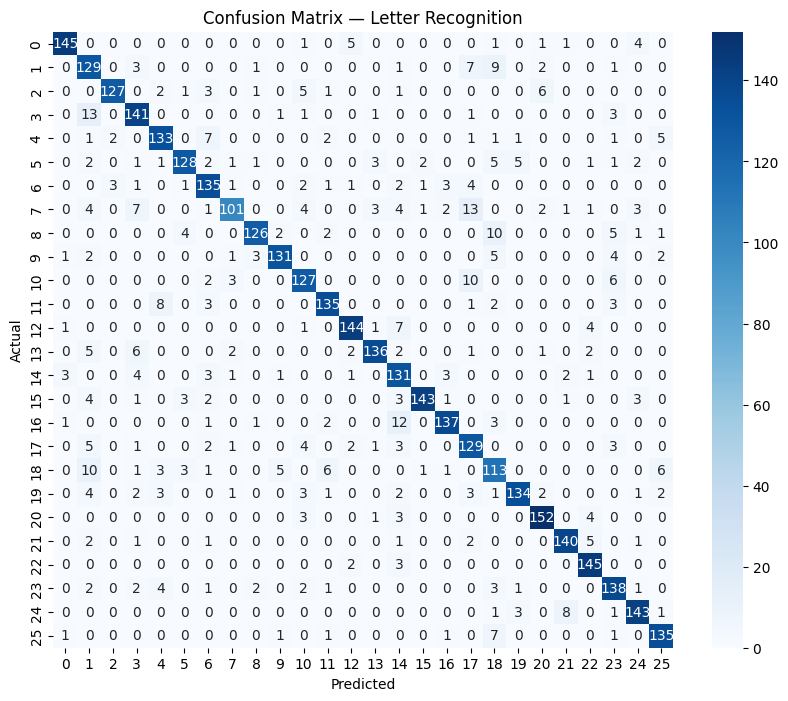

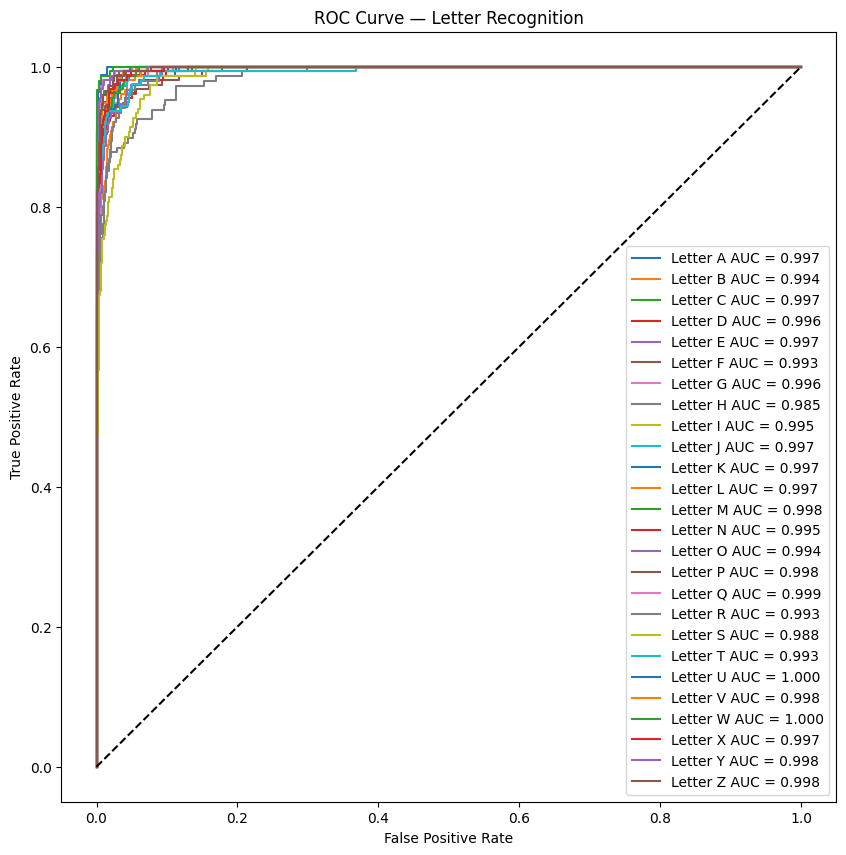

In [47]:
y_pred_prob = model_letter.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Letter Recognition")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr = {}
tpr = {}
roc_auc = {}

for i in range(26):
    fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10,10))
for i in range(26):
    plt.plot(fpr[i], tpr[i], label=f"Letter {label_encoder.inverse_transform([i])[0]} AUC = {roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Letter Recognition")
plt.legend()
plt.show()